In [54]:
import os
import torch
import numpy as np
import librosa 
import matplotlib.pyplot as plt

In [55]:
print("Pytorch Version :", torch.__version__)
print("librosa Verison " , librosa.__version__)


Pytorch Version : 2.9.1+cpu
librosa Verison  1.0.0


In [56]:
BASE_DIR = "."
TEACHERS_DIR = os.path.join(BASE_DIR, "audios_teachers")
LEARNERS_DIR = os.path.join(BASE_DIR, "audios_learners")
mapping_rules = {
    "sanskrit_shloka1": "shlokam1_responses",
    "sanskrit_shloka2": "shlokam2_responses",
    "sanskrit_shloka3": "shlokam3_responses",
    "sanskrit_shloka4": "shlokam4_responses",
    "sanskrit_shloka5": "shlokam5_responses",
    "telugu_padyam1": "padyam1_responses",
    "telugu_padyam2": "padyam2_responses",
    "telugu_padyam3": "padyam3_responses",
    "telugu_padyam4": "padyam4_responses",
    "telugu_padyam5": "padyam5_responses",
    "telugu_padyam6": "padyam6_responses",
}

all_pairs = []

for teacher_key, learner_folder_name in mapping_rules.items():
    teacher_file = os.path.join(TEACHERS_DIR, f"{teacher_key}.mp3")
    learner_folder_path = os.path.join(LEARNERS_DIR, learner_folder_name)
    
    if not os.path.exists(teacher_file):
        print(f"Teacher file missing: {teacher_file}")
        continue
    if not os.path.exists(learner_folder_path):
        print(f"Learner folder missing: {learner_folder_path}")
        continue
        
    weba_files = [f for f in os.listdir(learner_folder_path) if f.endswith(".weba")]
    
    for w_file in weba_files:
        learner_file = os.path.join(learner_folder_path, w_file)
        all_pairs.append({
            "utterance_id": teacher_key,
            "teacher_audio_path": teacher_file,
            "learner_audio_path": learner_file
        })

print(f"Total Reference Tasks: {len(mapping_rules)}")
print(f"Total (Teacher <-> Learner) Pairs Found: {len(all_pairs)}")

Total Reference Tasks: 11
Total (Teacher <-> Learner) Pairs Found: 100


In [5]:
!pip install av

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/27.6 MB 8.1 MB/s eta 0:00:04
   --- ------------------------------------ 2.1/27.6 MB 5.4 MB/s eta 0:00:05
   --- ------------------------------------ 2.4/27.6 MB 4.9 MB/s eta 0:00:06
   ---- ----------------------------------- 2.9/27.6 MB 3.6 MB/s eta 0:00:07
   ---- ----------------------------------- 3.1/27.6 MB 3.0 MB/s eta 0:00:09
   ----- ---------------------------------- 3.9/27.6 MB 3.2 MB/s eta 0:00:08
   ------- -------------------------------- 5.2/27.6 MB 3.5 MB/s eta 0:00:07
   --------- ------------------------------ 6.3/27.6 MB 3.7 MB/s eta 0:00:06
   ---------- ----------------------------- 7.1/27.6 MB 3.8 MB/s eta 0:00:06
   ----------- ---------------------------- 8.1/27.6 MB 3.9 MB/s eta 0:00:06
   ---------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Utterance ID       : sanskrit_shloka1
Teacher Image shape: (1, 128, 512)
Student Image shape: (1, 128, 512)


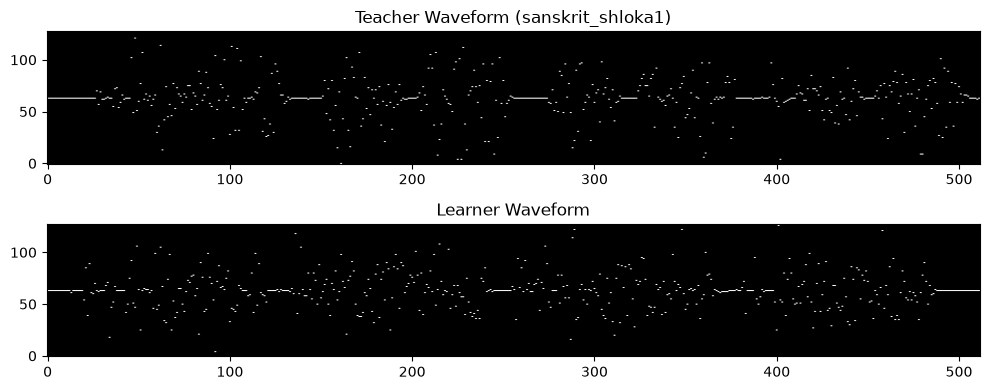

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import av

def read_audio(file_path, target_sr=16000):
    container = av.open(file_path)
    audio_stream = next(s for s in container.streams if s.type == 'audio')
    
    # Resample and convert to mono float32
    resampler = av.AudioResampler(format='flt', layout='mono', rate=target_sr)
    
    samples_list = []
    for frame in container.decode(audio_stream):
        resampled_frames = resampler.resample(frame)
        for r_frame in resampled_frames:
            samples_list.append(r_frame.to_ndarray())
            
    if not samples_list:
        return np.zeros(target_sr, dtype=np.float32)
        
    audio = np.concatenate(samples_list, axis=1).squeeze()
    return audio.astype(np.float32)

def make_waveform_img(wav_path, W=512, H=128):
    y = read_audio(wav_path, target_sr=16000)
    
    # 1. Temporal normalization (X-axis -> W steps)
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, W)
    y_interp = np.interp(x_new, x_old, y)
    
    # 2. Amplitude normalization to [0, 1] (Y-axis -> H steps)
    max_amp = np.abs(y_interp).max() + 1e-8
    y_norm = ((y_interp / max_amp) + 1.0) / 2.0
    y_idx = np.clip((y_norm * (H - 1)).astype(int), 0, H - 1)
    
    # 3. Construct 1-channel binary 2D image
    img = np.zeros((1, H, W), dtype=np.float32)
    for x in range(W):
        img[0, y_idx[x], x] = 1.0
        
    return img

# Test on the first teacher-learner pair
sample = all_pairs[0]
t_img = make_waveform_img(sample["teacher_audio_path"])
s_img = make_waveform_img(sample["learner_audio_path"])

print("Utterance ID       :", sample["utterance_id"])
print("Teacher Image shape:", t_img.shape)
print("Student Image shape:", s_img.shape)

plt.figure(figsize=(10, 4))

plt.subplot(2, 1, 1)
plt.imshow(t_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title(f"Teacher Waveform ({sample['utterance_id']})")

plt.subplot(2, 1, 2)
plt.imshow(s_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title("Learner Waveform")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import av

def read_audio(file_path, target_sr=16000):
    container = av.open(file_path)
    audio_stream = next(s for s in container.streams if s.type == 'audio')
    
    # Resample and convert to mono float32
    resampler = av.AudioResampler(format='flt', layout='mono', rate=target_sr)
    
    samples_list = []
    for frame in container.decode(audio_stream):
        resampled_frames = resampler.resample(frame)
        for r_frame in resampled_frames:
            samples_list.append(r_frame.to_ndarray())
            
    if not samples_list:
        return np.zeros(target_sr, dtype=np.float32)
        
    audio = np.concatenate(samples_list, axis=1).squeeze()
    return audio.astype(np.float32)

def make_waveform_img(wav_path, W=512, H=128):
    y = read_audio(wav_path, target_sr=16000)
    
    # 1. Temporal normalization (X-axis -> W steps)
    x_old = np.linspace(0, 1, len(y))
    x_new = np.linspace(0, 1, W)
    y_interp = np.interp(x_new, x_old, y)
    
    # 2. Amplitude normalization to [0, 1] (Y-axis -> H steps)
    max_amp = np.abs(y_interp).max() + 1e-8
    y_norm = ((y_interp / max_amp) + 1.0) / 2.0
    y_idx = np.clip((y_norm * (H - 1)).astype(int), 0, H - 1)
    
    # 3. Construct 1-channel binary 2D image
    img = np.zeros((1, H, W), dtype=np.float32)
    for x in range(W):
        img[0, y_idx[x], x] = 1.0
        
    return img

# Test on the first teacher-learner pair
sample = all_pairs[0]
t_img = make_waveform_img(sample["teacher_audio_path"])
s_img = make_waveform_img(sample["learner_audio_path"])

print("Utterance ID       :", sample["utterance_id"])
print("Teacher Image shape:", t_img.shape)
print("Student Image shape:", s_img.shape)

plt.figure(figsize=(10, 4))

plt.subplot(2, 1, 1)
plt.imshow(t_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title(f"Teacher Waveform ({sample['utterance_id']})")

plt.subplot(2, 1, 2)
plt.imshow(s_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title("Learner Waveform")

plt.tight_layout()
plt.show()

Utterance ID: telugu_padyam1


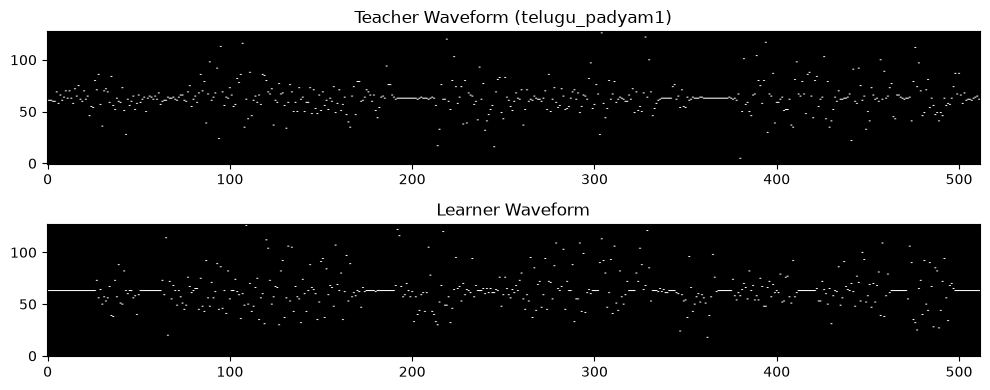

In [58]:
# Telugu Padyam 1 ka pair check karte hain
telugu_sample = [p for p in all_pairs if "telugu_padyam1" in p["utterance_id"]][0]

t_telugu_img = make_waveform_img(telugu_sample["teacher_audio_path"])
s_telugu_img = make_waveform_img(telugu_sample["learner_audio_path"])

print("Utterance ID:", telugu_sample["utterance_id"])

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.imshow(t_telugu_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title(f"Teacher Waveform ({telugu_sample['utterance_id']})")

plt.subplot(2, 1, 2)
plt.imshow(s_telugu_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title("Learner Waveform")
plt.tight_layout()
plt.show()

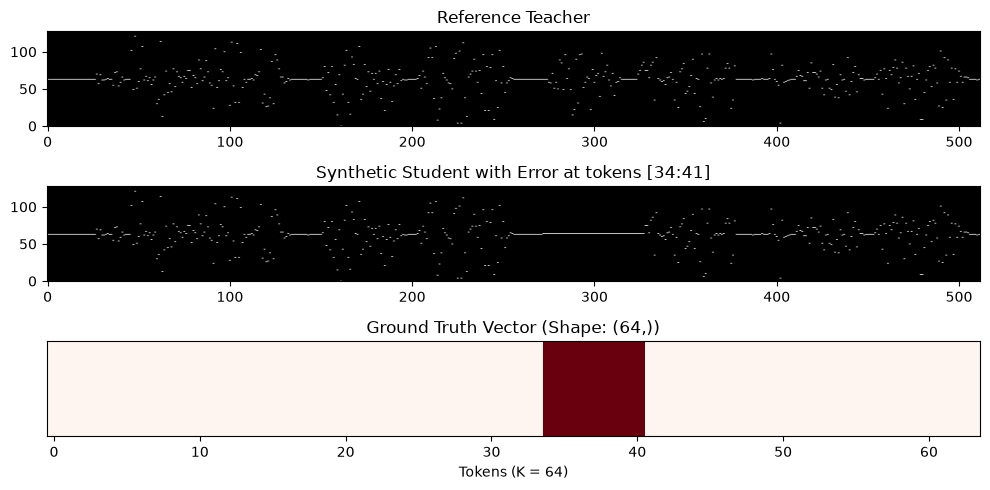

In [26]:
def create_synthetic_pair(teacher_img, K=64, W=512, H=128):
    # Teacher image ki copy banayi
    synth_student = teacher_img.copy()
    chunk_w = W // K  # 512 // 64 = 8 pixels per token
    
    # Random token range jahan mismatch create karenge (e.g. token 20 se 30)
    span = np.random.randint(4 , 13)
    k_start = np.random.randint(0 , K-span)
    k_end = k_start + span
    
    x_start = k_start * chunk_w
    x_end = k_end * chunk_w
    
    # Waveform ko is region me distort/zero kiya
    if np.random.rand() > 0.5:

     synth_student[0, :, x_start:x_end] = 0.0
     synth_student[0, H // 2, x_start:x_end] = 1.0  # flat line (silence)
    else :
       #noise jitter
       synth_student[0, :, x_start:x_end] = 0.0
       rand_y = np.random.randint(0, H, size=(x_end - x_start,))
       for idx, col in enumerate(range(x_start, x_end)):
            synth_student[0, rand_y[idx], col] = 1.0
    # Ground Truth Mask Vector banaya (Size = K = 64)
    # 0 = Match, 1 = Error / Difference
    gt_mask = np.zeros(K, dtype=np.float32)
    gt_mask[k_start:k_end] = 1.0
    
    return synth_student, gt_mask, (k_start, k_end)

synth_img, gt_vec, (k_s, k_e) = create_synthetic_pair(t_img, K=64)

plt.figure(figsize=(10, 5))
plt.subplot(3, 1, 1)
plt.imshow(t_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title("Reference Teacher")

plt.subplot(3, 1, 2)
plt.imshow(synth_img[0], cmap="gray", origin="lower", aspect="auto")
plt.title(f"Synthetic Student with Error at tokens [{k_s}:{k_e}]")

plt.subplot(3, 1, 3)
plt.imshow(gt_vec[np.newaxis, :], cmap="Reds", aspect="auto")
plt.title(f"Ground Truth Vector (Shape: {gt_vec.shape})")
plt.yticks([])
plt.xlabel("Tokens (K = 64)")
plt.tight_layout()
plt.show()

In [27]:
import torch
import torch.nn as nn

class ResNetTokenizer(nn.Module):
    def __init__(self, embed_dim=128, K=64):
        super().__init__()
        self.K = K
        
        # ResNet-style 2D convolutional feature extractor
        self.features = nn.Sequential(
            # Layer 1: [B, 1, 128, 512] -> [B, 32, 64, 256]
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            # Layer 2: [B, 32, 64, 256] -> [B, 64, 32, 128]
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            # Layer 3: [B, 64, 32, 128] -> [B, 128, 16, 64]
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            # Temporal Chunk Pooling -> [B, 128, 1, K=64]
            nn.AdaptiveAvgPool2d((1, K))
        )
        
        # Token projection layer
        self.proj = nn.Linear(128, embed_dim)

    def forward(self, img):
        # img: [B, 1, H, W]
        x = self.features(img)                # [B, 128, 1, K]
        x = x.squeeze(2).permute(0, 2, 1)     # [B, K, 128]
        tokens = self.proj(x)                 # [B, K, embed_dim]
        return tokens

# Quick test of Tokenizer on our single sample images
tokenizer = ResNetTokenizer(embed_dim=128, K=64)

# Convert numpy images to PyTorch tensors with batch dimension
t_tensor = torch.tensor(t_img).unsqueeze(0)      # [1, 1, 128, 512]
s_tensor = torch.tensor(synth_img).unsqueeze(0)  # [1, 1, 128, 512]

# Tokenize using the same theta
teacher_tokens = tokenizer(t_tensor)
student_tokens = tokenizer(s_tensor)

print("Teacher Tokens Shape (t) :", teacher_tokens.shape)  # Expected: [1, 64, 128]
print("Student Tokens Shape (s) :", student_tokens.shape)  # Expected: [1, 64, 128]

Teacher Tokens Shape (t) : torch.Size([1, 64, 128])
Student Tokens Shape (s) : torch.Size([1, 64, 128])


In [28]:
class TransformerCrossAttentionBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4):
        super().__init__()
        # Cross-Attention: Query comes from Student, Key/Value come from Teacher
        self.cross_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        
        # Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, s, t):
        # s: student tokens [B, K, D] (Query)
        # t: teacher tokens [B, K, D] (Key, Value)
        attn_out, _ = self.cross_attn(query=s, key=t, value=t)
        s = self.norm1(s + attn_out)
        
        # Feed-forward residual
        ffn_out = self.ffn(s)
        s = self.norm2(s + ffn_out)
        return s

class PronunciationVerifier(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, num_layers=3, K=64):
        super().__init__()
        # Shared ResNet Tokenizer (parameterized on theta)
        self.tokenizer = ResNetTokenizer(embed_dim=embed_dim, K=K)
        
        # Stack of i Transformer Cross-Attention blocks
        self.blocks = nn.ModuleList([
            TransformerCrossAttentionBlock(embed_dim=embed_dim, num_heads=num_heads)
            for _ in range(num_layers)
        ])
        
        # combine(si, t) -> Linear projection -> pred_mask
        self.combine_proj = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embed_dim, 1),
            nn.Sigmoid()  # Mask probability in [0, 1]
        )

    def forward(self, teacher_img, student_img):
        # 1. Tokenize using shared theta
        t = self.tokenizer(teacher_img)  # [B, K, D]
        s = self.tokenizer(student_img)  # [B, K, D]
        
        # 2. Multi-block cross attention: s attends to t
        si = s
        for block in self.blocks:
            si = block(si, t)
            
        # 3. Combine refined student tokens and teacher tokens
        combined = torch.cat([si, t], dim=-1)  # [B, K, 2*D]
        
        # 4. Predict mask tokens and reshape
        mask_tokens = self.combine_proj(combined)  # [B, K, 1]
        pred_mask = mask_tokens.squeeze(-1)        # [B, K]
        return pred_mask

# Instantiate model and test forward pass
model = PronunciationVerifier(embed_dim=128, num_heads=4, num_layers=3, K=64)

# Pass our test sample tensors
pred_mask = model(t_tensor, s_tensor)

print("Predicted Mask Shape :", pred_mask.shape)  # Expected: [1, 64]
print("GT Mask Shape        :", gt_vec.shape)     # Expected: (64,)
print("Sample initial predictions (first 10 tokens):\n", pred_mask[0, :10].detach().numpy().round(3))

Predicted Mask Shape : torch.Size([1, 64])
GT Mask Shape        : (64,)
Sample initial predictions (first 10 tokens):
 [0.556 0.576 0.576 0.573 0.564 0.57  0.542 0.537 0.542 0.547]


In [29]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =====================================================================
# 1. DYNAMIC SYNTHETIC DATASET (11 Teacher Utterances)
# =====================================================================
class MultilingualSyntheticDataset(Dataset):
    def __init__(self, pairs_list, num_samples=500, K=64, W=512, H=128):
        # Extract unique 11 teacher audio file paths
        unique_teacher_paths = list(set([p["teacher_audio_path"] for p in pairs_list]))
        print(f"Pre-rasterizing {len(unique_teacher_paths)} Teacher Waveform Images...")
        
        self.teacher_images = [make_waveform_img(p, W=W, H=H) for p in unique_teacher_paths]
        self.num_samples = num_samples
        self.K = K
        self.W = W
        self.H = H
        print("Caching complete!")

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Select one random reference audio (Sanskrit or Telugu)
        t_img = self.teacher_images[np.random.randint(0, len(self.teacher_images))]
        
        # Synthesize error and GT mask on-the-fly
        synth_img, gt_mask, _ = create_synthetic_pair(t_img, K=self.K, W=self.W, H=self.H)
        
        return (
            torch.tensor(t_img, dtype=torch.float32),        # [1, H, W]
            torch.tensor(synth_img, dtype=torch.float32),    # [1, H, W]
            torch.tensor(gt_mask, dtype=torch.float32)       # [K]
        )

# =====================================================================
# 2. TRAINING SETUP
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Dataset and DataLoader
train_dataset = MultilingualSyntheticDataset(all_pairs, num_samples=600, K=64)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Initialize Model, L2 Loss (MSE), and Optimizer
model = PronunciationVerifier(embed_dim=128, num_heads=4, num_layers=3, K=64).to(device)
criterion = nn.MSELoss()  # ||GT - pred_mask||_2^2
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# =====================================================================
# 3. TRAINING LOOP
# =====================================================================
epochs = 15
print("\n--- Starting Synthetic Pre-Training ---")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for t_batch, s_batch, gt_batch in train_loader:
        t_batch = t_batch.to(device)
        s_batch = s_batch.to(device)
        gt_batch = gt_batch.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        pred_mask = model(t_batch, s_batch)
        
        # L2 Loss computation
        loss = criterion(pred_mask, gt_batch)
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * t_batch.size(0)
        
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch [{epoch+1:02d}/{epochs:02d}]  |  L2 Loss: {epoch_loss:.6f}")

print("\n Synthetic Pre-Training Complete!")

Training on device: cpu
Pre-rasterizing 11 Teacher Waveform Images...
Caching complete!

--- Starting Synthetic Pre-Training ---
Epoch [01/15]  |  L2 Loss: 0.069187
Epoch [02/15]  |  L2 Loss: 0.018104
Epoch [03/15]  |  L2 Loss: 0.008865
Epoch [04/15]  |  L2 Loss: 0.006043
Epoch [05/15]  |  L2 Loss: 0.005510
Epoch [06/15]  |  L2 Loss: 0.004862
Epoch [07/15]  |  L2 Loss: 0.005021
Epoch [08/15]  |  L2 Loss: 0.004071
Epoch [09/15]  |  L2 Loss: 0.003718
Epoch [10/15]  |  L2 Loss: 0.026495
Epoch [11/15]  |  L2 Loss: 0.032182
Epoch [12/15]  |  L2 Loss: 0.009820
Epoch [13/15]  |  L2 Loss: 0.005207
Epoch [14/15]  |  L2 Loss: 0.006219
Epoch [15/15]  |  L2 Loss: 0.004541

 Synthetic Pre-Training Complete!


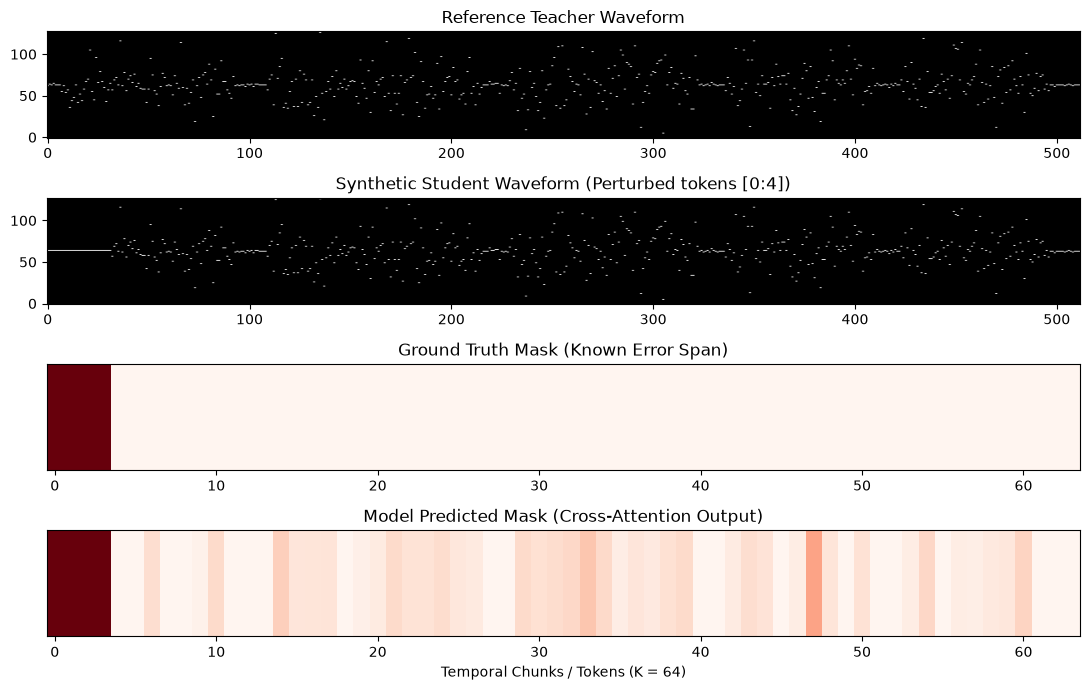

In [30]:
model.eval()

# Generate a fresh, unseen test sample
sample_teacher = train_dataset.teacher_images[0]
test_synth_student, test_gt_mask, (k_s, k_e) = create_synthetic_pair(sample_teacher, K=64)

with torch.no_grad():
    t_in = torch.tensor(sample_teacher).unsqueeze(0).to(device)
    s_in = torch.tensor(test_synth_student).unsqueeze(0).to(device)
    test_pred_mask = model(t_in, s_in).cpu().squeeze(0).numpy()

# Visual Comparison: Teacher, Synthetic Student, GT Mask, and Model Prediction
plt.figure(figsize=(11, 7))

plt.subplot(4, 1, 1)
plt.imshow(sample_teacher[0], cmap="gray", origin="lower", aspect="auto")
plt.title("Reference Teacher Waveform")

plt.subplot(4, 1, 2)
plt.imshow(test_synth_student[0], cmap="gray", origin="lower", aspect="auto")
plt.title(f"Synthetic Student Waveform (Perturbed tokens [{k_s}:{k_e}])")

plt.subplot(4, 1, 3)
plt.imshow(test_gt_mask[np.newaxis, :], cmap="Reds", aspect="auto", vmin=0, vmax=1)
plt.title("Ground Truth Mask (Known Error Span)")
plt.yticks([])

plt.subplot(4, 1, 4)
plt.imshow(test_pred_mask[np.newaxis, :], cmap="Reds", aspect="auto", vmin=0, vmax=1)
plt.title("Model Predicted Mask (Cross-Attention Output)")
plt.xlabel("Temporal Chunks / Tokens (K = 64)")
plt.yticks([])

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

model.eval()
evaluation_results = []

print(f"Evaluating {len(all_pairs)} Real Student Recordings...")

with torch.no_grad():
    for pair in all_pairs:
        t_img = make_waveform_img(pair["teacher_audio_path"])
        s_img = make_waveform_img(pair["learner_audio_path"])
        
        t_tensor = torch.tensor(t_img).unsqueeze(0).to(device)
        s_tensor = torch.tensor(s_img).unsqueeze(0).to(device)
        
        # Predict error mask
        pred_mask = model(t_tensor, s_tensor).cpu().squeeze(0).numpy()
        
        # Threshold at 0.5 to mark mismatched chunks
        error_flags = (pred_mask > 0.5).astype(int)
        error_count = int(np.sum(error_flags))
        accuracy_score = (1.0 - (error_count / len(error_flags))) * 100.0
        
        evaluation_results.append({
            "Utterance_ID": pair["utterance_id"],
            "Language": "Sanskrit" if "sanskrit" in pair["utterance_id"] else "Telugu",
            "Learner_Audio": os.path.basename(pair["learner_audio_path"]),
            "Error_Tokens_Count": error_count,
            "Pronunciation_Accuracy (%)": round(accuracy_score, 2),
            "Mean_Mismatch_Intensity": round(float(np.mean(pred_mask)), 4)
        })

# Format results into DataFrame
df_results = pd.DataFrame(evaluation_results)
print("\nEvaluation Completed!")
print(f"Overall Average Pronunciation Score: {df_results['Pronunciation_Accuracy (%)'].mean():.2f}%")

# Grouped Summary by Utterance Task
summary_table = df_results.groupby(["Language", "Utterance_ID"])[["Pronunciation_Accuracy (%)", "Mean_Mismatch_Intensity"]].mean().reset_index()
print("\n--- Performance Summary Across Tasks ---")
print(summary_table.to_string(index=False))

Evaluating 100 Real Student Recordings...

Evaluation Completed!
Overall Average Pronunciation Score: 77.39%

--- Performance Summary Across Tasks ---
Language     Utterance_ID  Pronunciation_Accuracy (%)  Mean_Mismatch_Intensity
Sanskrit sanskrit_shloka1                   80.540000                 0.198218
Sanskrit sanskrit_shloka2                   84.091818                 0.161718
Sanskrit sanskrit_shloka3                   82.244545                 0.182336
Sanskrit sanskrit_shloka4                   68.040909                 0.311300
Sanskrit sanskrit_shloka5                   69.726250                 0.307837
  Telugu   telugu_padyam1                   74.530000                 0.254800
  Telugu   telugu_padyam2                   82.814444                 0.180956
  Telugu   telugu_padyam3                   74.025000                 0.259463
  Telugu   telugu_padyam4                   76.335714                 0.236000
  Telugu   telugu_padyam5                   72.768571      

In [33]:
# Filter for just sanskrit_shloka1 responses
shloka1_df = df_results[df_results["Utterance_ID"] == "sanskrit_shloka1"]
print(f"Total responses for sanskrit_shloka1: {len(shloka1_df)}")
print(shloka1_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for sanskrit_shloka1: 11
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
20f05867-eaf1-4d9c-b703-704188acd4d6.weba                       64.06                  23
3fc3f4e3-6d30-46e3-93ba-cb23db457f86.weba                       81.25                  12
4c37be69-cd4d-4618-81aa-819c11e794bd.weba                       89.06                   7
734c8c5e-533d-4047-ba38-bb38a9c7466a.weba                       70.31                  19
7c257cbb-c882-43a4-a7e1-873feef89167.weba                       87.50                   8
7fc37acb-cf8a-479e-b751-c0a160b37bb3.weba                       73.44                  17
880c5e55-036d-42a8-ab40-ac84c6d4585f.weba                       95.31                   3
98ec221d-0416-475e-8aa1-7d397a2a0b7e.weba                       73.44                  17
a4495e5d-d338-4635-9e2c-8febca1ae163.weba                       79.69                  13
bac60d55-e048-476a-a530-1ac60ed4279c.weba                  

In [ ]:
# Filter for just sanskrit_shloka2 responses
shloka2_df = df_results[df_results["Utterance_ID"] == "sanskrit_shloka2"]
print(f"Total responses for sanskrit_shloka2: {len(shloka2_df)}")
print(shloka2_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for sanskrit_shloka2: 11
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
00b59f5c-4876-4de2-b668-15d6b964ff3a.weba                       85.94                   9
44c33acf-d7c5-4d12-8ecf-0b01eb861660.weba                       73.44                  17
616fe5ee-e044-4397-bf63-7a40df88b959.weba                       87.50                   8
62d5fdf5-dd1f-46df-890a-137bb90a904b.weba                       92.19                   5
648fde69-2555-4943-89e7-6fe1126112d3.weba                      100.00                   0
8ac54c03-340c-404e-bb91-28f634923e9e.weba                       76.56                  15
a74f13ec-9506-4ad6-b9ec-580393a635e5.weba                       85.94                   9
b30b7ad3-1aeb-4c17-8077-f67245036cce.weba                       92.19                   5
be810bcb-90e7-4ed7-8baf-18c76dc9f79b.weba                       82.81                  11
d66c12e7-e9e2-4ad3-b29d-71e43de43ebc.weba                  

In [ ]:
# Filter for just sanskrit_shloka3 responses
shloka3_df = df_results[df_results["Utterance_ID"] == "sanskrit_shloka3"]
print(f"Total responses for sanskrit_shloka3: {len(shloka3_df)}")
print(shloka3_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for sanskrit_shloka3: 11
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
015e20ad-08c0-4191-91b3-78418da6077e.weba                       75.00                  16
1f24e4e0-da8a-4dff-8b0a-36fbc98a9cec.weba                       82.81                  11
343bdf50-a63a-403e-8e7e-70b004241ceb.weba                       84.38                  10
4b3b83b2-fdc7-4399-bcfa-d9a856882465.weba                       81.25                  12
5971d8db-7d8b-4e4e-9f6a-cbe7f322c115.weba                       92.19                   5
7ce1cd1a-c7a9-40f5-9b7e-9dfa8d5057b0.weba                       81.25                  12
7d1497a9-84b5-4de8-a398-9d6fb678a9be.weba                       76.56                  15
afc3d5b2-c952-4066-a695-cc214ac53cb8.weba                       92.19                   5
bb0cde4e-6c6f-479a-b711-78fc67c75039.weba                       70.31                  19
c0b98d7a-60e2-4481-8725-58a009406a09.weba                  

In [ ]:
# Filter for just sanskrit_shloka4 responses
shloka4_df = df_results[df_results["Utterance_ID"] == "sanskrit_shloka4"]
print(f"Total responses for sanskrit_shloka4: {len(shloka4_df)}")
print(shloka4_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for sanskrit_shloka4: 11
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
084c91f2-510a-4c7b-aeb3-14ec74496886.weba                       68.75                  20
23ea4120-59ec-4a98-96bf-2694a7f75a1c.weba                       59.38                  26
2b06f6d5-8c32-4c4f-b9f9-e46190830a71.weba                       87.50                   8
454af37c-3a92-45de-930d-af7ec99a9aba.weba                       62.50                  24
6f1eb475-da00-4240-beb5-883aa1dfde6b.weba                       54.69                  29
9eed4af5-dd05-41ba-8f37-26af66098d76.weba                       81.25                  12
ac6182b6-6436-4233-9cb2-3fa3d651637a.weba                       79.69                  13
c3df3bf3-b178-4a0b-b986-3a8a44ce890a.weba                       89.06                   7
ca9827fc-0b5c-4d8f-a24c-421604880b80.weba                       45.31                  35
ccb99c96-b79d-4db5-9c9a-0e7556430bcd.weba                  

In [ ]:
# Filter for just sanskrit_shloka5 responses
shloka5_df = df_results[df_results["Utterance_ID"] == "sanskrit_shloka5"]
print(f"Total responses for sanskrit_shloka5: {len(shloka5_df)}")
print(shloka5_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for sanskrit_shloka5: 8
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
1888d006-3344-49db-af07-6a5753b92e1a.weba                       50.00                  32
1fb75b4a-66f5-4509-a485-bf3f4f07f77c.weba                       95.31                   3
22dde9f4-34ab-4703-a3b4-150b431d3961.weba                       79.69                  13
3ea52ff7-ce4e-4c1e-8945-a3d97e7aa38a.weba                       87.50                   8
56ec93f8-c9fe-4f77-83f0-7269f892cd69.weba                       57.81                  27
af328e8a-b15f-4320-ab32-1fcceebf2f48.weba                       81.25                  12
d7eda512-e86a-4bb4-a6b5-0e477914f9de.weba                       60.94                  25
e2b0f81a-7095-4add-b664-b4c26b036336.weba                       45.31                  35


In [43]:
# Specific check for telugu_padyam1
padyam1_df = df_results[df_results["Utterance_ID"] == "telugu_padyam1"]
print(f"Total responses for telugu_padyam1: {len(padyam1_df)}")
print(padyam1_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for telugu_padyam1: 10
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
279096ad-95b7-4012-b1eb-f396bc84f421.weba                       62.50                  24
29c21c42-5ab3-4b48-b1f3-0e4bba401d7c.weba                       65.62                  22
3a0e866f-6b02-41bd-bd5c-843c294e6dbf.weba                       90.62                   6
7a957d30-4f96-425c-8d52-d2b89fcd2542.weba                       82.81                  11
99fea830-94e4-4ab9-952c-2c5cc4d713cc.weba                       75.00                  16
b5cfcae1-c41e-41e1-83e7-568106377947.weba                       82.81                  11
bd36fc31-8af5-4027-adb1-c674d5b43d93.weba                       54.69                  29
c2d2cd51-db20-40ad-b5f9-9bb5217cbb3c.weba                       85.94                   9
d0dc59e5-a1e0-4374-8801-3ebc1cedf2f0.weba                       64.06                  23
d922fff1-3ec8-4c16-8909-927b8d1cbdfc.weba                    

In [44]:
# Specific check for telugu_padyam2
padyam2_df = df_results[df_results["Utterance_ID"] == "telugu_padyam2"]
print(f"Total responses for telugu_padyam2: {len(padyam2_df)}")
print(padyam2_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for telugu_padyam2: 9
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
1f43458a-30de-493b-86fe-6423a221a3a0.weba                       93.75                   4
3613a60b-a5a3-4ce0-9705-fcc814ebdfbc.weba                       84.38                  10
398201b0-f56f-4565-aafe-91386fa1e2bc.weba                       87.50                   8
4fbd2787-0319-42b1-88aa-ca66a8f4e319.weba                       92.19                   5
54e6efe6-f6c8-4c2c-b98c-ea0275728cab.weba                       67.19                  21
9b940750-24f0-476a-817a-cf9fe30b83a7.weba                       60.94                  25
a68d1be3-399e-47af-b1d6-0b482ac86e72.weba                       92.19                   5
c9d68d6b-29aa-4ac7-81b3-8693bd01bdea.weba                       98.44                   1
de46b0af-32d8-4a77-b941-f3fa1f82913a.weba                       68.75                  20


In [ ]:
# Specific check for telugu_padyam3
padyam3_df = df_results[df_results["Utterance_ID"] == "telugu_padyam3"]
print(f"Total responses for telugu_padyam3: {len(padyam3_df)}")
print(padyam3_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for telugu_padyam1: 8
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
060d78eb-fa31-487e-830e-880cb791810a.weba                       54.69                  29
06fe34f8-a336-4893-980d-d14ec3b40eaf.weba                       85.94                   9
09f4017a-0ea0-4668-93ab-794fa755d668.weba                       93.75                   4
67819c2d-4d99-4390-8b2b-3b9eb610e53a.weba                       73.44                  17
919311e1-8203-4e58-97e4-862db64f5b78.weba                       78.12                  14
a4371497-a5d9-4923-92e8-aca3cad45104.weba                       84.38                  10
a54cf740-efa4-4369-a42e-db7dec9edc19.weba                       50.00                  32
dfbfa6ff-392e-4cf3-b456-8782fe92de52.weba                       71.88                  18


In [47]:
# Specific check for telugu_padyam4
padyam4_df = df_results[df_results["Utterance_ID"] == "telugu_padyam4"]
print(f"Total responses for telugu_padyam4: {len(padyam4_df)}")
print(padyam4_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for telugu_padyam4: 7
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
1457fe1b-4c4b-4c8f-873c-c5d9306819aa.weba                       82.81                  11
70631d05-a771-47c1-be10-ccbcb9ef10ea.weba                       89.06                   7
789d4877-e3bc-4ed9-8d82-0c6934f54e4e.weba                       90.62                   6
78d41f17-f744-4d25-98cd-84a338394746.weba                       78.12                  14
7cb1a74a-d6a5-4ab3-a4e9-efb26745bdbb.weba                       65.62                  22
9e91eea0-d2dc-4f06-bbf7-1b42bfe72ad9.weba                       70.31                  19
b41742fd-4b4a-4d3b-917c-93e3f1819567.weba                       57.81                  27


In [49]:
# Specific check for telugu_padyam5
padyam5_df = df_results[df_results["Utterance_ID"] == "telugu_padyam5"]
print(f"Total responses for telugu_padyam5: {len(padyam5_df)}")
print(padyam5_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for telugu_padyam5: 7
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
4752cf19-452e-4579-bd97-3adbfd57f398.weba                       84.38                  10
8e329c09-db60-4545-9902-330b588ff431.weba                       81.25                  12
95c443a5-9af2-48c2-b501-50ca634856f0.weba                       62.50                  24
995f64c7-97d8-44ac-b8d7-68daf02d6bef.weba                       60.94                  25
d1e383c5-9391-44a7-a4c0-a8eded145570.weba                       76.56                  15
df932376-eb34-4850-b979-6ed404b0bfc9.weba                       64.06                  23
f3a3d25f-927a-4914-b5fd-cd4909c83c2d.weba                       79.69                  13


In [50]:
# Specific check for telugu_padyam6
padyam6_df = df_results[df_results["Utterance_ID"] == "telugu_padyam6"]
print(f"Total responses for telugu_padyam6: {len(padyam6_df)}")
print(padyam6_df[["Learner_Audio", "Pronunciation_Accuracy (%)", "Error_Tokens_Count"]].to_string(index=False))

Total responses for telugu_padyam6: 7
                            Learner_Audio  Pronunciation_Accuracy (%)  Error_Tokens_Count
288c23c2-e27e-4906-bb86-4ed922e73c94.weba                       78.12                  14
2e43dc45-f683-4702-9f2a-af18c4dfbb04.weba                       85.94                   9
47303f43-3091-43ee-b3e6-9bb176ecec07.weba                       73.44                  17
7a091762-c13a-4240-9704-bd7738d2cd16.weba                       93.75                   4
acb62e8a-6fdb-4b28-aa2a-67a07e71313b.weba                       95.31                   3
b7f27979-e19d-44e9-9c0d-86a958db766e.weba                       71.88                  18
f07a0ec3-3013-44d5-98d3-53e7ced8f25a.weba                       92.19                   5


=== Cross-Language Independence Evaluation ===
Language  Total_Audios  Mean_Accuracy  Std_Deviation  Mean_Mismatch_Intensity
Sanskrit            52      77.344231      13.836252                 0.227923
  Telugu            48      77.441458      12.557718                 0.226763


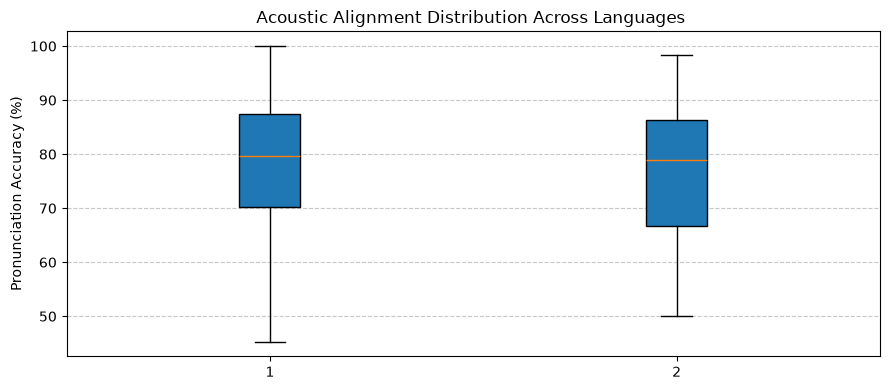

In [ ]:
# -------------------------------------------------------------
# Cross-Language Independence Validation (Sanskrit vs Telugu)
# -------------------------------------------------------------
lang_summary = df_results.groupby("Language").agg(
    Total_Audios=('Learner_Audio', 'count'),
    Mean_Accuracy=('Pronunciation_Accuracy (%)', 'mean'),
    Std_Deviation=('Pronunciation_Accuracy (%)', 'std'),
    Mean_Mismatch_Intensity=('Mean_Mismatch_Intensity', 'mean')
).reset_index()

print("=== Cross-Language Independence Evaluation ===")
print(lang_summary.to_string(index=False))

# Visualization: Distribution Comparison
plt.figure(figsize=(9, 4))
plt.boxplot([
    df_results[df_results["Language"] == "Sanskrit"]["Pronunciation_Accuracy (%)"],
    df_results[df_results["Language"] == "Telugu"]["Pronunciation_Accuracy (%)"]
], patch_artist=True)
plt.xticks([1, 2], ["Sanskrit Shlokas", "Telugu Padyams"])
plt.title("Acoustic Alignment Distribution Across Languages ")
plt.ylabel("Pronunciation Accuracy (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()